# P-Wave Arrival Picker

Regression CNN that predicts the P-wave arrival sample index from a 60-second waveform.  
All logic lives in `src/picker/` — this notebook trains and evaluates the model.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../../..').resolve()))  # project root

import matplotlib.pyplot as plt
from src.picker.model import PickerCNN
from src.picker.train import train
from src.picker.evaluate import evaluate

DATA = str(Path('../../../data').resolve())
CKPT = str(Path('../../../checkpoints/picker_best.pt').resolve())

In [2]:
n_params = sum(p.numel() for p in PickerCNN().parameters())
assert n_params == 20001, (
    f"Loaded a stale PickerCNN ({n_params} params, expected 20001 — "
    "the flatten+linear head). Restart the kernel so the edited "
    "src/picker/model.py is re-imported, then re-run this cell."
)
print(f"PickerCNN OK — {n_params} params (flatten+linear head loaded).")

PickerCNN OK — 20001 params (flatten+linear head loaded).


## Train
Loads ~116K earthquake waveforms into RAM, then trains for up to 30 epochs with early stopping.  
Comment out `train()` and set `history = None` if you already have a checkpoint.

In [3]:
history = train({"data_dir": DATA, "checkpoint_path": CKPT, "epochs": 15})

Using device: cpu
Loading datasets into RAM...
Train: 116,084 traces  |  Val: 29,007 traces


C:\Users\tomer\OneDrive\Documents\Computational Science\earthquake-classifier\src\picker\train.py:75: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))


Epoch  1/15  train_loss=4.0500 s  val_MAE=1.4419 s
Epoch  2/15  train_loss=1.2771 s  val_MAE=1.2081 s
Epoch  3/15  train_loss=1.1203 s  val_MAE=1.0235 s
Epoch  4/15  train_loss=0.7726 s  val_MAE=0.5038 s
Epoch  5/15  train_loss=0.4622 s  val_MAE=0.4234 s
Epoch  6/15  train_loss=0.4180 s  val_MAE=0.4186 s
Epoch  7/15  train_loss=0.4015 s  val_MAE=0.3924 s
Epoch  8/15  train_loss=0.3897 s  val_MAE=0.3863 s
Epoch  9/15  train_loss=0.3759 s  val_MAE=0.3695 s
Epoch 10/15  train_loss=0.3602 s  val_MAE=0.3570 s
Epoch 11/15  train_loss=0.3486 s  val_MAE=0.3513 s
Epoch 12/15  train_loss=0.3398 s  val_MAE=0.3435 s
Epoch 13/15  train_loss=0.3345 s  val_MAE=0.3410 s
Epoch 14/15  train_loss=0.3308 s  val_MAE=0.3367 s
Epoch 15/15  train_loss=0.3291 s  val_MAE=0.3361 s
Best val MAE: 0.3361 s  —  checkpoint saved to C:\Users\tomer\OneDrive\Documents\Computational Science\earthquake-classifier\checkpoints\picker_best.pt


## Training curves

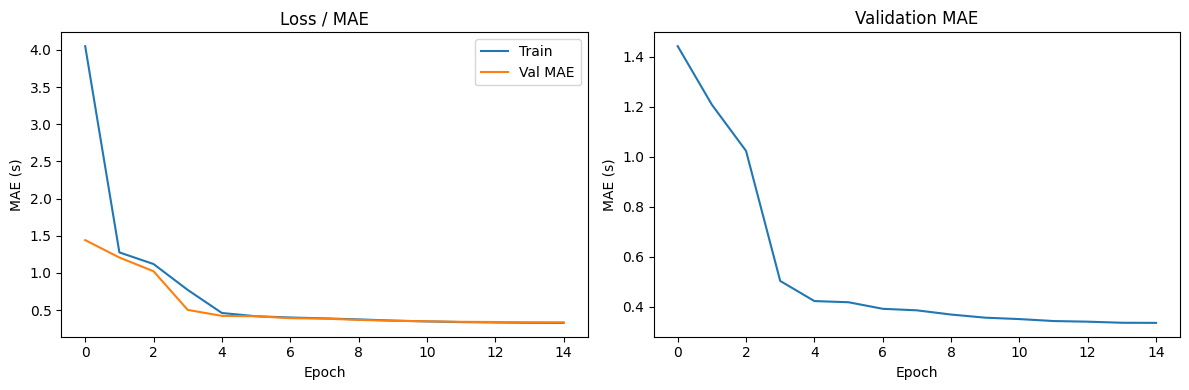

In [4]:
if history:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_mae'],    label='Val MAE')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE (s)')
    axes[0].set_title('Loss / MAE')
    axes[0].legend()

    axes[1].plot(history['val_mae'])
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE (s)')
    axes[1].set_title('Validation MAE')

    plt.tight_layout()
    plt.show()

## Evaluate
Loads the checkpoint and test set once, then prints MAE, plots residuals, and plots example predictions.

Loading test set...
Test MAE: 33.7 samples  (0.3365 s)


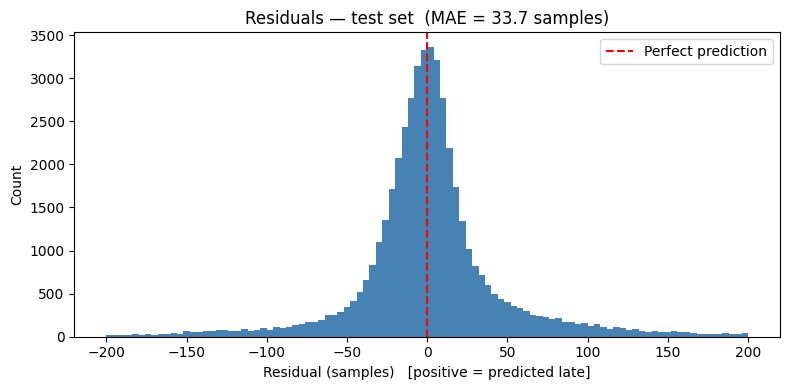

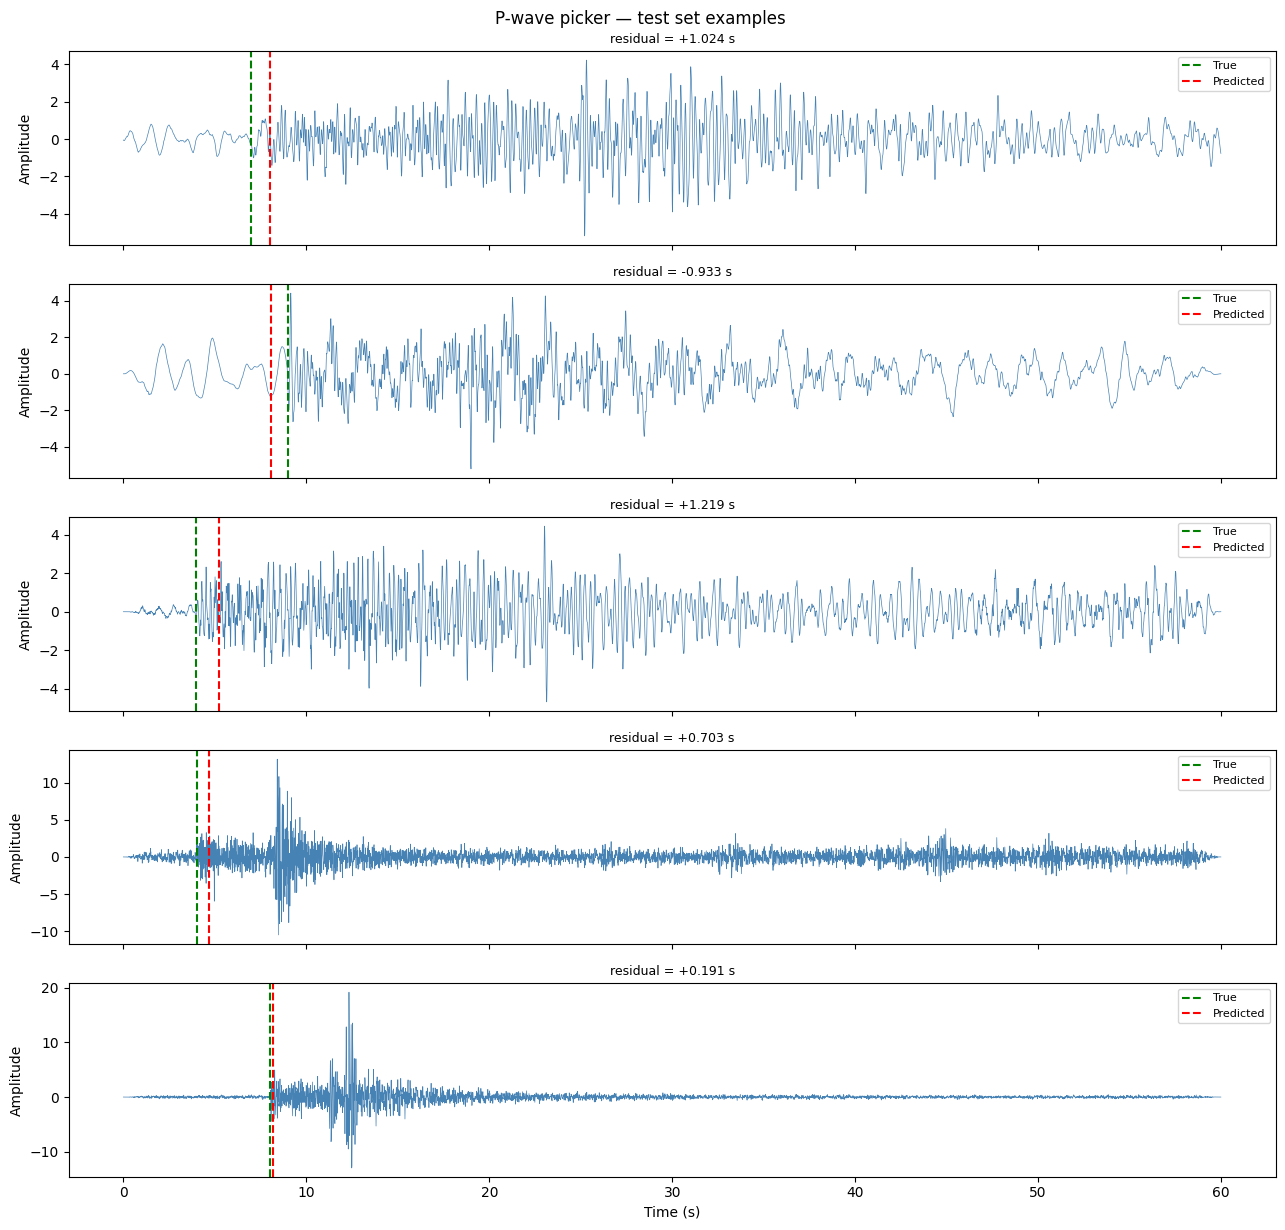

0.3365121078491211

In [5]:
evaluate(CKPT, DATA)